# Confidence intervals for cell-line recommendations

**What this notebook does.** Given a gene, the recommendation pipeline scores every cell line with a
single number, `core_score` between 0 and 1 — higher means the line is a better fit for studying that
gene. But a score on its own doesn't tell you *how sure* we are. Two lines can both score 0.98 while
one is rock-solid and the other could easily have landed at 0.6 if the measurements had come out a
little differently.

This notebook adds that missing piece. For any gene it produces, per cell line:

- a **confidence interval** around the score — a low/high range the score plausibly occupies, and
- two **stability numbers** — how often the line lands in the top 10 (once against every line, once
  against only lines from the same tissue), and how often it comes out as the single best.


**The idea in one line.** We take the measurements that feed the score, jitter them by an amount
equal to how uncertain each measurement actually is, recompute the score, and repeat ~1000 times.
The spread of the recomputed scores is the confidence interval; how often a line stays on top is its
stability. Crucially, the jitter size is *read from the data itself* (how much the data sources
disagree), not guessed.

## Before you run this

The notebook reads a few files the main pipeline produces. You don't build them here — you just need
them to exist. In order, the pipeline creates:

| File | Made by | What it holds |
|---|---|---|
| `bulk_rna_z.parquet` | the RNA scoring step | each line's combined RNA score per gene |
| `bulk_prot_z.parquet` | the protein scoring step | each line's combined protein score per gene |
| `protein_platform_tier.parquet` | `platform_tier.py` | how much the two protein platforms agree, per protein |
| `core_score.parquet` | `core_score.py` | the final score we put intervals around |
| `prot_resid_stats.parquet` | `core_score.py` | three constants per gene the interval needs (see below) |

That last file matters. `core_score.py` combines RNA and protein using a few per-gene constants
(a regression coefficient and a centring/scaling pair). To reproduce the score *exactly*, this
notebook reads those constants rather than re-deriving them — re-deriving from a single gene gives
slightly different numbers and the scores drift. If `prot_resid_stats.parquet` is missing, re-run
`core_score.py` once; it writes that file alongside `core_score.parquet`.

You also need the warehouse database (`celllineselector.db`) and the helper modules `common.py` and
`protein_scorer.py` on the path — the setup cell below points Python at them.

## Setup

In [2]:
import sys
from pathlib import Path

# point Python at the pipeline so `config`, `common`, `protein_scorer` import
PIPELINE_ROOT = Path("/Users/musa.official/Documents/UoB-GeneTraceAI-25-26/final_pipeline").resolve()      # <-- set this
for p in (PIPELINE_ROOT, PIPELINE_ROOT / "utils",
          PIPELINE_ROOT / "02_Proteinomics", PIPELINE_ROOT / "Scoring"):
    sp = str(p)
    if sp not in sys.path:
        sys.path.insert(0, sp)

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

### Constants and noise knobs

The first block **must match `core_score.py`** — these are the weights and floors the pipeline uses,
copied here so our recomputed score is identical to the stored one. The second block are the only new
numbers: how big to make the jitter. They're deliberately conservative and exposed so you can test how
sensitive the results are to them.

- `RNA_BASE_FLOOR` — a small baseline wobble every RNA measurement carries.
- `RNA_TAU_PRIOR` — the jitter for a line measured by only **one** RNA source (there's no
  disagreement to observe, so we fall back to a typical value).
- `COVERAGE_CAP` — caps how much a thinly-measured line's jitter can grow.
- `PROT_TIER_MULT` — scales protein jitter by how well the two protein platforms agree for that gene
  (`consistent` → small, `conflicting` → large).

In [3]:
# --- must match core_score.py ---
W_RNA  = np.sqrt(1.431)
W_PROT = np.sqrt(1.45)
W_NORM = np.sqrt(W_RNA**2 + W_PROT**2)
MAD_FLOOR = 0.384
RNA_SOURCES_TOTAL = 3

# --- noise knobs (assumed parameters(design choices) can be optimized) ---
RNA_BASE_FLOOR = 0.30
RNA_TAU_PRIOR  = 0.25
COVERAGE_CAP   = 1.5
PROT_BASE      = 0.30
PROT_TIER_MULT = {"consistent": 1.0, "cautious": 1.5, "conflicting": 2.2}
PROT_TAU_PRIOR = 0.45

## Step 1 — find a gene's ID

You'll ask for a gene by its familiar symbol (like `EGFR`); the pipeline stores genes by their Ensembl
ID (like `ENSG00000146648`). This looks up one from the other. It accepts either form.

In [4]:
def _resolve_gid(con, gene):
    g = str(gene).strip()
    if g.upper().startswith("ENSG"):
        return g.upper()
    row = con.execute(
        "SELECT gene_id FROM gene WHERE lower(hugo_symbol) = lower(?) LIMIT 1", [g]
    ).fetchone()
    if not row:
        raise ValueError(f"gene not found: {gene}")
    return row[0].upper()

## Step 2 — RNA inputs and their uncertainty

For the queried gene we need two things per cell line: the **RNA score** (the point value, which we
read straight from the stored `bulk_rna_z.parquet` so it matches the pipeline exactly), and **how
uncertain that score is** (which we work out from the raw sources).

The RNA score combines up to three sources (DepMap, GEO, HPA). When two or three of them measured a
line, we can *see* how much they disagree — that disagreement is the uncertainty, no guessing needed.
When only one source measured a line, there's nothing to compare, so we fall back to a typical value
(`RNA_TAU_PRIOR`) and widen a bit more for the thin coverage. The helper `_rna_per_source` fetches the
individual source values purely to measure that disagreement.

In [5]:
def _rna_per_source(con, gid):
    '''Fetch each RNA source's z-score for one gene — used ONLY to measure
    how much the sources disagree (the point score comes from bulk_rna_z).'''
    import common as C
    gid = str(gid).lower()                       # warehouse tables are lowercase
    lineage_map = C.load_lineage(con)
    def _wide(long):
        return long.pivot_table(index="model_id", columns="gene_id", values="value", aggfunc="median")
    frames = []
    for fetch, name in [(C.fetch_depmap, "depmap_expr"),
                        (C.fetch_geo,    "geo_expr"),
                        (C.fetch_hpa,    "hpa_rna")]:
        long = fetch(con, [gid])
        if len(long):
            frames.append(C.score_source_lineage(_wide(long), [gid], lineage_map, name))
    if not frames:
        return pd.DataFrame(columns=["model_id", "source", "z"])
    return pd.concat(frames, ignore_index=True)[["model_id", "source", "z"]].dropna()


def rna_leaves(con, gene):
    '''Per-line RNA point score (from bulk_rna_z) + its uncertainty se_rna.'''
    import common as C
    from config import RNA_Z
    gid = _resolve_gid(con, gene).upper()

    # point score: read the pipeline's own value so the centre matches exactly
    rz = pd.read_parquet(RNA_Z).rename(columns={"z_t": "rna_z"})
    rz["gene_id"] = rz["gene_id"].str.upper()
    rz = rz[rz.gene_id == gid][["model_id", "rna_z", "n_sources"]].copy()
    rz["model_id"] = rz["model_id"].str.lower()
    lineage_map = C.load_lineage(con); lineage_map.index = lineage_map.index.str.lower()
    rz["lineage"] = rz["model_id"].map(lineage_map)

    # uncertainty: disagreement between sources (only measurable when >= 2 sources)
    per = _rna_per_source(con, gid)
    if len(per):
        per["model_id"] = per["model_id"].str.lower()
        disp = (per.groupby("model_id")["z"].agg(["std", "count"])
                   .rename(columns={"std": "s_between", "count": "k_obs"}))
        rz = rz.merge(disp, on="model_id", how="left")
    else:
        rz["s_between"], rz["k_obs"] = np.nan, np.nan

    k = rz["n_sources"].to_numpy()
    se_between = np.where(k >= 2, rz["s_between"].to_numpy() / np.sqrt(np.maximum(k, 1)), RNA_TAU_PRIOR)
    se_between = np.where(np.isfinite(se_between), se_between, RNA_TAU_PRIOR)
    se_within  = RNA_BASE_FLOOR * np.minimum(np.sqrt(RNA_SOURCES_TOTAL / np.maximum(k, 1)), COVERAGE_CAP)
    rz["se_rna"] = np.sqrt(se_between**2 + se_within**2)
    return rz[["model_id", "rna_z", "n_sources", "s_between", "se_rna", "lineage"]]

## Step 3 — protein inputs and their uncertainty

Same pattern for protein. The point score comes straight from `bulk_prot_z.parquet`. For the
uncertainty, protein has only two platforms (ProCAN and CCLE), so per-line disagreement is too thin to
trust; instead we scale the jitter by how well the two platforms agree **for this gene overall** — the
`consistent / cautious / conflicting` tier from `protein_platform_tier.parquet`. A gene where the
platforms agree gets a tight protein band; a `conflicting` gene gets a wide one.

A gene absent from the tier file (measured on too few shared lines, or on ProCAN only) is not an error
— it falls back to `cautious`, and a line measured on a single platform carries the extra
`PROT_TAU_PRIOR` term.

In [6]:
def protein_leaves(con, gene, default_tier="cautious"):
    '''Per-line protein point score (from bulk_prot_z) + its uncertainty se_prot.
    Empty frame if the gene has no protein measurement at all.'''
    import protein_scorer as PS
    from config import PROT_Z, PROT_TIER

    empty = pd.DataFrame(columns=["model_id", "prot_z", "n_platforms", "se_prot"])
    gid = _resolve_gid(con, gene).upper()

    pz = pd.read_parquet(PROT_Z).rename(columns={"z_t": "prot_z"})
    pz["gene_id"] = pz["gene_id"].str.upper()
    pz = pz[pz.gene_id == gid][["model_id", "prot_z", "n_sources"]].copy()
    if pz.empty:
        return empty
    pz["model_id"] = pz["model_id"].str.lower()

    # gene-level platform agreement -> jitter scale
    u2e = PS._build_uniprot_ensg(con)
    uniprots = {u for u, e in u2e.items() if e == gid}
    tier_df = pd.read_parquet(PROT_TIER); tier_df["uniprot"] = tier_df["uniprot"].str.lower()
    trow = tier_df.loc[tier_df["uniprot"].isin(uniprots)]
    tier = str(trow.sort_values("platform_rho").iloc[0]["platform_tier"]) if len(trow) else default_tier

    mult = PROT_TIER_MULT.get(tier, 1.5)
    pz = pz.rename(columns={"n_sources": "n_platforms"})
    prior = np.where(pz["n_platforms"] < 2, PROT_TAU_PRIOR, 0.0)   # 1-platform lines carry the prior
    pz["se_prot"] = np.sqrt((mult * PROT_BASE)**2 + prior**2)
    return pz[["model_id", "prot_z", "n_platforms", "se_prot"]]

## Step 4 — recomputing the score

This reproduces the pipeline's scoring for one gene. Step by step: rank each line's RNA score within
its tissue and turn that rank into a z-score; form the protein *residual* (the part of protein not
already explained by RNA) and standardise it using the gene's stored constants; combine the two with
their weights; map to 0–1 with the normal CDF. Lines with no protein use the RNA part alone.

The three constants `BETA_G`, `RESID_MED`, `RESID_SD` come from the stored `prot_resid_stats.parquet`
— using the pipeline's own values here is exactly what makes the recomputed score match the stored one
to the last decimal.

In [7]:
def core_score_chain(df, BETA_G=0.0, RESID_MED=0.0, RESID_SD=1.0):
    d = df.copy()
    # RNA: rank within tissue, then to a z-score
    d["rna_pct"]   = d.groupby("lineage")["rna_z"].rank(pct=True, ascending=True, method="average")
    d["rna_pct_z"] = stats.norm.ppf(np.clip(d["rna_pct"].values, 0.001, 0.999))
    # protein residual, standardised with the gene's stored constants
    has_p = d["prot_z"].notna()
    resid = np.where(has_p, d["prot_z"] - BETA_G * d["rna_z"], np.nan)
    resid_z = np.full(len(d), np.nan)
    resid_z[has_p.values] = (resid[has_p.values] - RESID_MED) / RESID_SD
    d["prot_resid_z"] = resid_z
    # combine (RNA-only lines use the RNA part alone)
    core_z_2 = (W_RNA * d["rna_pct_z"] + W_PROT * d["prot_resid_z"]) / W_NORM
    d["core_z"]     = np.where(has_p, core_z_2, d["rna_pct_z"])
    d["core_score"] = stats.norm.cdf(d["core_z"].values)
    d["n_layers"]   = np.where(has_p, 2, 1)          # 2 = RNA+protein, 1 = RNA only
    return d[["model_id", "lineage", "core_score", "n_layers"]]

## Step 5 — the simulation

Now the core loop. `N` times, we nudge every line's RNA and protein score by a random amount sized to
its uncertainty, recompute all the scores, and rank the lines twice — once against **all** lines
(global) and once against only **same-tissue** lines. Recording where each line lands across all the
runs gives us: the interval (2.5th–97.5th percentile of its scores), and the stability numbers (how
often it's in the top 10, and how often it's the single best).

The very first, un-nudged pass is the "centre" — it must equal the stored `core_score`, which we check
later. The interval is clamped to always contain that centre.

In [8]:
def monte_carlo_ci(rna_leaves, prot_leaves, gid, N=1000, k=10, seed=42, ci=0.95, anchor=None):
    rng  = np.random.default_rng(seed)
    base = rna_leaves.merge(prot_leaves, on="model_id", how="left")

    # the gene's three residual constants: from prot_resid_stats.parquet, or passed in (demo)
    if anchor is not None:
        BETA_G, RESID_MED, RESID_SD = anchor["beta_g"], anchor["resid_med"], anchor["resid_sd"]
    else:
        from config import CORE_SCORE
        _st = pd.read_parquet(CORE_SCORE.parent / "prot_resid_stats.parquet")
        _st["ensg_id"] = _st["ensg_id"].str.upper()
        _row = _st[_st.ensg_id == gid.upper()]
        if len(_row):
            BETA_G, RESID_MED, RESID_SD = (float(_row.beta_g.iloc[0]),
                                           float(_row.resid_med.iloc[0]), float(_row.resid_sd.iloc[0]))
        else:                                        # RNA-only gene — these go unused
            BETA_G, RESID_MED, RESID_SD = 0.0, 0.0, 1.0

    centre = core_score_chain(base, BETA_G, RESID_MED, RESID_SD).set_index("model_id")
    ids = base["model_id"].to_numpy(); n = len(base)
    scores = np.empty((N, n))
    top_global = np.zeros(n); top_lineage = np.zeros(n); win1 = np.zeros(n)

    rna_mu, rna_sd = base["rna_z"].to_numpy(), base["se_rna"].to_numpy()
    has_p = base["prot_z"].notna().to_numpy()
    prot_mu = base["prot_z"].to_numpy(float); prot_sd = base["se_prot"].to_numpy(float)
    lineage = base["lineage"].to_numpy()

    for i in range(N):
        draw = base[["model_id", "lineage"]].copy()
        draw["rna_z"] = rna_mu + rng.normal(0, 1, n) * rna_sd
        pz = np.full(n, np.nan)
        pz[has_p] = prot_mu[has_p] + rng.normal(0, 1, has_p.sum()) * prot_sd[has_p]
        draw["prot_z"] = pz
        s = core_score_chain(draw, BETA_G, RESID_MED, RESID_SD).set_index("model_id").loc[ids, "core_score"].to_numpy()
        scores[i] = s
        order = np.argsort(-s)
        top_global[order[:k]] += 1; win1[order[0]] += 1
        tmp = pd.DataFrame({"s": s, "lin": lineage})
        tmp["r"] = tmp.groupby("lin")["s"].rank(ascending=False, method="first")
        top_lineage[(tmp["r"] <= k).to_numpy()] += 1

    lo, hi = (1 - ci) / 2, 1 - (1 - ci) / 2
    out = pd.DataFrame({
        "model_id": ids, "lineage": lineage,
        "core_score": centre.loc[ids, "core_score"].to_numpy(),
        "ci_lo": np.quantile(scores, lo, axis=0), "ci_hi": np.quantile(scores, hi, axis=0),
        "topk_global_pct": 100*top_global/N, "topk_lineage_pct": 100*top_lineage/N,
        "top1_winrate": 100*win1/N,
        "n_layers": centre.loc[ids, "n_layers"].to_numpy(),
        "n_sources": base["n_sources"].to_numpy(),
    })
    out["ci_lo"] = np.minimum(out["ci_lo"], out["core_score"])   # keep the point inside the band
    out["ci_hi"] = np.maximum(out["ci_hi"], out["core_score"])
    out["ci_width"] = out["ci_hi"] - out["ci_lo"]
    return out.sort_values("core_score", ascending=False).reset_index(drop=True), scores, ids


def run_gene_ci(con, gene, N=1000, k=10, seed=42):
    '''One call: fetch inputs for `gene`, simulate, return the per-line table.'''
    rna  = rna_leaves(con, gene)
    prot = protein_leaves(con, gene)
    gid  = _resolve_gid(con, gene).upper()
    return monte_carlo_ci(rna, prot, gid=gid, N=N, k=k, seed=seed)

## Running it on your database

With the database connected, a single call does everything. This is the real entry point:

```python
import duckdb
con = duckdb.connect(str(DB), read_only=True)          # DB from `from config import DB`
res, scores, ids = run_gene_ci(con, "EGFR", N=1000, k=10)
res.head(12)
```

`res` is the per-line table (one row per cell line, sorted best first). `scores` is the full
simulation array (used for the distribution plot). The cell is left commented so the notebook runs
end-to-end without a database; uncomment it once your path and `con` are set.

In [22]:
import duckdb
from config import DB
con = duckdb.connect(str(DB), read_only=True)
res, scores, ids = run_gene_ci(con, "EGFR", N=1000, k=10)
res.head(12)

,model_id,lineage,core_score,ci_lo,ci_hi,topk_global_pct,topk_lineage_pct,top1_winrate,n_layers,n_sources,ci_width
0,ach-000620,liver,0.99959,0.939652,0.999972,35.8,100.0,25.3,2,2,0.060319
1,ach-001321,thyroid,0.99900,0.611111,0.999000,17.0,99.7,0.6,1,2,0.387889
2,ach-000469,central_nervous_system,0.99900,0.956522,0.999000,27.7,100.0,0.6,1,2,0.042478
3,ach-000561,esophagus,0.99900,0.968750,0.999000,36.7,100.0,1.2,1,2,0.030250
4,ach-000088,fibroblast,0.99900,0.102564,0.999000,11.2,76.6,0.2,1,2,0.896436
5,ach-001064,lymphocyte,0.99900,0.294737,0.999000,17.9,84.0,0.5,1,2,0.704263
6,ach-000864,uterus,0.99900,0.825000,0.999000,13.4,98.7,0.2,1,2,0.174000
7,ach-000862,urinary_tract,0.99900,0.864865,0.999000,33.7,99.9,0.6,1,2,0.134135
8,ach-000431,lung,0.99900,0.897436,0.999000,7.8,77.9,0.1,1,2,0.101564
9,ach-001193,bone,0.99900,0.925000,0.999000,39.2,99.9,0.4,1,2,0.074000


## Checking the recompute matches the pipeline

The single most important check: with the noise turned off, our recomputed score must equal the
stored `core_score` for every line. If it does, the intervals are built on the real score, not an
approximation of it. Run this after a real `run_gene_ci`; a clean result is `max|Δ|` around `1e-7`.

```python
from config import CORE_SCORE
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core["ensg_id"].str.upper()
gid  = _resolve_gid(con, "EGFR").upper()
ref  = core[core.ensg_id == gid].assign(model_id=lambda d: d.model_id.str.lower())
got  = res.assign(model_id=lambda d: d.model_id.str.lower())
m = got.merge(ref[["model_id","core_score"]].rename(columns={"core_score":"ref"}), on="model_id")
print("compared:", len(m), "| max|Δ|:", (m.core_score - m.ref).abs().max())
```

In [24]:
from config import CORE_SCORE
core = pd.read_parquet(CORE_SCORE); core["ensg_id"] = core["ensg_id"].str.upper()
gid  = _resolve_gid(con, "EGFR").upper()
ref  = core[core.ensg_id == gid].assign(model_id=lambda d: d.model_id.str.lower())
got  = res.assign(model_id=lambda d: d.model_id.str.lower())
m = got.merge(ref[["model_id","core_score"]].rename(columns={"core_score":"ref"}), on="model_id")
print("compared:", len(m), "| max|Δ|:", (m.core_score - m.ref).abs().max())

compared: 1039 | max|Δ|: 6.699557475453588e-08


## Reading the output

Each row is one cell line. The columns:

- **`core_score`** — the fit score (0–1), same as the pipeline. Near the top it saturates toward 1.0,
  so the interval and win-rate carry the information the score alone can't.
- **`ci_lo`, `ci_hi`, `ci_width`** — the 95% interval and its width. Wide means the score would move a
  lot under realistic measurement noise; narrow means it's stable.
- **`top1_winrate`** — how often (%) this line is the single best across all lines. The honest
  "is it *the* best?" number.
- **`topk_global_pct`** vs **`topk_lineage_pct`** — how often it's in the top 10 against every line
  vs against only same-tissue lines. A line can be rock-solid in its tissue but contested globally.
- **`n_layers`** — 2 if it has both RNA and protein, 1 if RNA only. **`n_sources`** — how many RNA
  sources (1–3) measured it; fewer means a wider interval.

### Figure 1 — the recommendations, with their intervals

Each line's score (dot) and its 95% interval (bar), best at the top, with the win-rate on the right.
Where the bars overlap heavily near the top, the ranking is genuinely uncertain — that's the whole
point of showing intervals rather than a bare ordering.

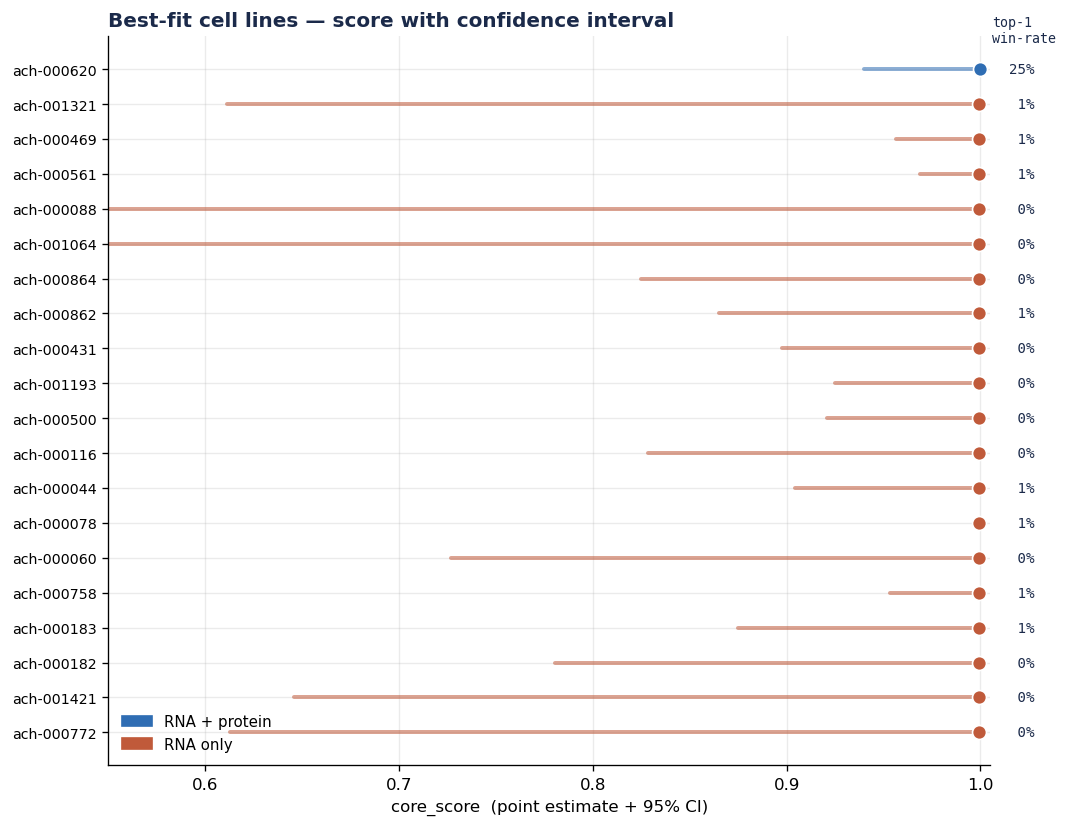

In [25]:
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,"axes.axisbelow":True})
INK, C2, C1 = "#1b2a4a", "#2f6db3", "#c05a3a"

top = res.head(20).iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 7))
for i, r in top.iterrows():
    col = C2 if r.n_layers == 2 else C1
    ax.plot([r.ci_lo, r.ci_hi], [i, i], color=col, lw=2.4, alpha=.55, solid_capstyle="round")
    ax.scatter(r.core_score, i, color=col, s=70, zorder=3, edgecolor="white", lw=1)
    ax.text(1.006, i, f"{r.top1_winrate:4.0f}%", va="center", ha="left", fontsize=8.5,
            family="monospace", color=INK)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.model_id, fontsize=8.5)
ax.set_xlabel("core_score  (point estimate + 95% CI)"); ax.set_xlim(0.55, 1.005)
ax.set_title("Best-fit cell lines — score with confidence interval", fontweight="bold", color=INK, loc="left")
ax.text(1.006, len(top)-0.3, "top-1\nwin-rate", fontsize=8, color=INK, ha="left", va="bottom", family="monospace")
ax.legend(handles=[Patch(color=C2, label="RNA + protein"), Patch(color=C1, label="RNA only")],
          loc="lower left", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### Sorting the ranking for display

`core_score` saturates near 1.0 for the top line of each tissue (it's a within-tissue percentile),
so sorting by it leaves the top of the ranking as a pile of ~0.999 ties in arbitrary order. The
scores are correct and unchanged — but for a readable figure we sort by the numbers that actually
discriminate among those ties: the top-1 win-rate and the global top-10 stability, with `core_score`
only as a final tie-breaker. This reorders rows for display; it does not alter any score or interval.

In [26]:
# Display-only ordering: break the 0.999 ties with the stability numbers.
# core_score / ci / win-rate values are unchanged — only the row order differs.
res_display = res.sort_values(
    ["top1_winrate", "topk_global_pct", "core_score"],
    ascending=False,
).reset_index(drop=True)

res_display.head(12)[["model_id","lineage","core_score","ci_lo","ci_hi",
                      "top1_winrate","topk_global_pct","n_layers","n_sources"]].round(3)

,model_id,lineage,core_score,ci_lo,ci_hi,top1_winrate,topk_global_pct,n_layers,n_sources
0,ach-000620,liver,1.000,0.940,1.000,25.3,35.8,2,2
1,ach-000638,lung,0.999,0.956,1.000,22.2,36.4,2,2
2,ach-000480,liver,0.997,0.965,1.000,17.6,29.0,2,2
3,ach-000883,central_nervous_system,0.997,0.957,1.000,4.6,11.5,2,3
4,ach-000115,prostate,0.996,0.791,1.000,3.3,9.7,2,2
5,ach-000580,skin,0.993,0.924,0.999,1.6,5.7,2,3
6,ach-000430,ovary,0.970,0.598,0.999,1.6,3.7,2,2
7,ach-000561,esophagus,0.999,0.969,0.999,1.2,36.7,1,2
8,ach-000699,breast,0.973,0.866,0.999,1.1,2.8,2,3
9,ach-000183,plasma_cell,0.999,0.875,0.999,1.0,29.1,1,2


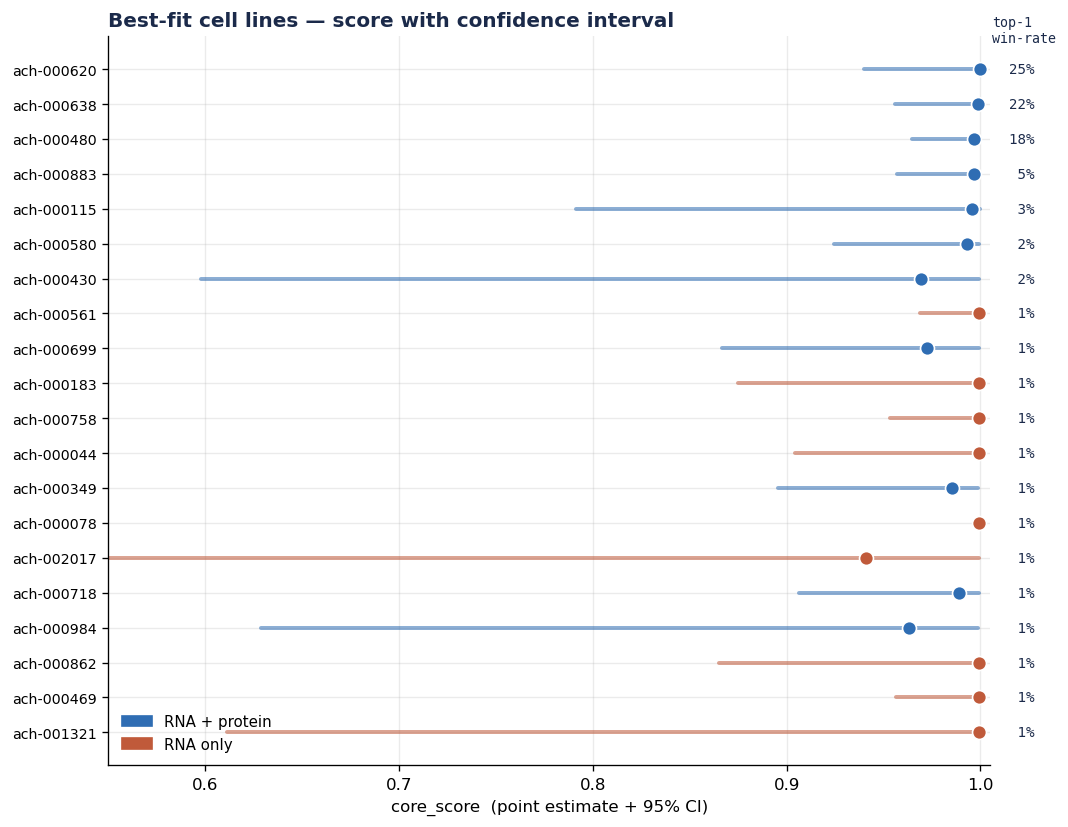

In [27]:
plt.rcParams.update({"figure.dpi":120,"font.size":10,"axes.spines.top":False,
                     "axes.spines.right":False,"axes.grid":True,"grid.alpha":.25,"axes.axisbelow":True})
INK, C2, C1 = "#1b2a4a", "#2f6db3", "#c05a3a"

top = res_display.head(20).iloc[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 7))
for i, r in top.iterrows():
    col = C2 if r.n_layers == 2 else C1
    ax.plot([r.ci_lo, r.ci_hi], [i, i], color=col, lw=2.4, alpha=.55, solid_capstyle="round")
    ax.scatter(r.core_score, i, color=col, s=70, zorder=3, edgecolor="white", lw=1)
    ax.text(1.006, i, f"{r.top1_winrate:4.0f}%", va="center", ha="left", fontsize=8.5,
            family="monospace", color=INK)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.model_id, fontsize=8.5)
ax.set_xlabel("core_score  (point estimate + 95% CI)"); ax.set_xlim(0.55, 1.005)
ax.set_title("Best-fit cell lines — score with confidence interval", fontweight="bold", color=INK, loc="left")
ax.text(1.006, len(top)-0.3, "top-1\nwin-rate", fontsize=8, color=INK, ha="left", va="bottom", family="monospace")
ax.legend(handles=[Patch(color=C2, label="RNA + protein"), Patch(color=C1, label="RNA only")],
          loc="lower left", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

### Figure 2 — same uncertainty, two rankings

Each dot is a line: how stable it is against **all** lines (x) versus against only its **own tissue**
(y). Points high on the left are solid within their tissue but contested globally — typically the
strong lines of a crowded tissue. Same noise, different crowd.

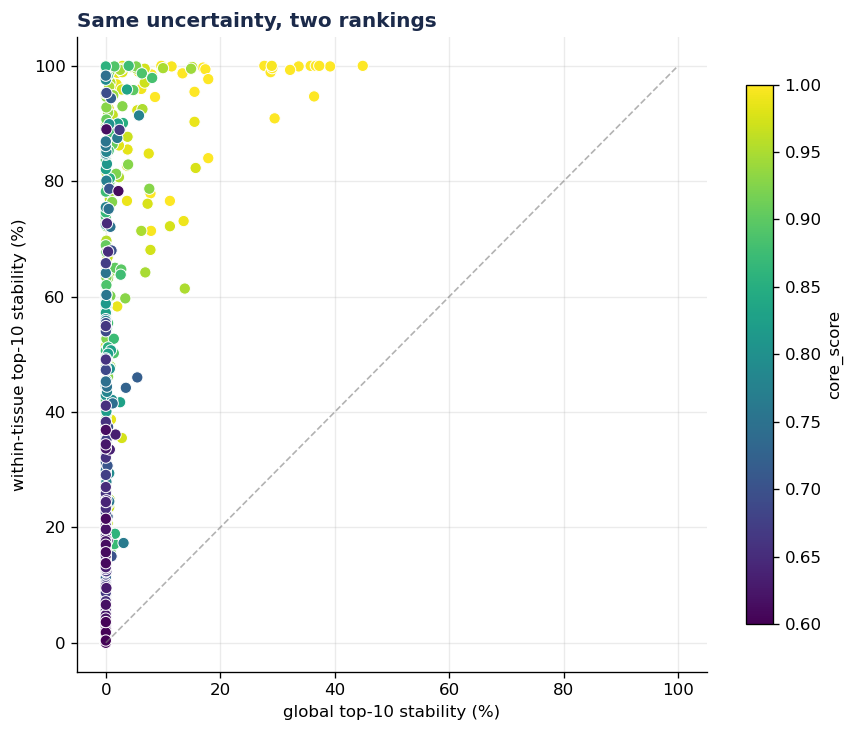

In [28]:
d = res[res.core_score > 0.6]
fig, ax = plt.subplots(figsize=(7.4, 6.2))
sc = ax.scatter(d.topk_global_pct, d.topk_lineage_pct, c=d.core_score, cmap="viridis",
                s=46, edgecolor="white", lw=.6, vmin=.6, vmax=1)
ax.plot([0,100],[0,100],"--",color="gray",lw=1,alpha=.6)
ax.set_xlabel("global top-10 stability (%)"); ax.set_ylabel("within-tissue top-10 stability (%)")
ax.set_title("Same uncertainty, two rankings", fontweight="bold", color=INK, loc="left")
fig.colorbar(sc, label="core_score", shrink=.85); plt.tight_layout(); plt.show()

### Figure 3 — the uncertainty is read from the data

Interval width against how many RNA sources measured the line. Lines seen by only one source are
widest; those seen by all three are tightest. Nobody set these widths by hand — they come out of how
much the sources disagree.

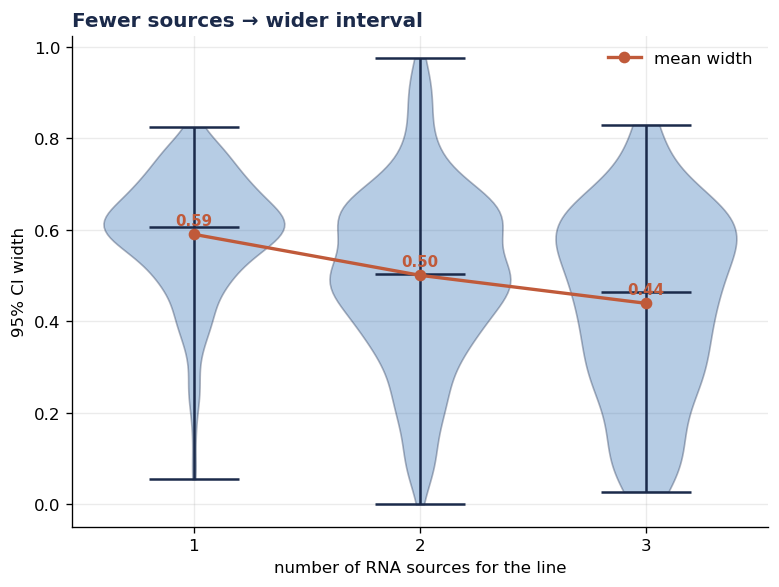

In [29]:
fig, ax = plt.subplots(figsize=(6.6, 5.0))
groups = [res[res.n_sources == kk]["ci_width"].values for kk in (1, 2, 3)]
groups = [g for g in groups if len(g)]
parts = ax.violinplot(groups, positions=range(1, len(groups)+1), showmedians=True, widths=.8)
for b in parts["bodies"]: b.set_facecolor(C2); b.set_alpha(.35); b.set_edgecolor(INK)
for key in ("cmedians","cbars","cmins","cmaxes"): parts[key].set_color(INK)
means = [g.mean() for g in groups]
ax.plot(range(1, len(groups)+1), means, "o-", color=C1, lw=2, label="mean width", zorder=3)
for x, mu in zip(range(1, len(groups)+1), means):
    ax.text(x, mu + .02, f"{mu:.2f}", ha="center", color=C1, fontsize=9, fontweight="bold")
ax.set_xticks(range(1, len(groups)+1)); ax.set_xlabel("number of RNA sources for the line")
ax.set_ylabel("95% CI width"); ax.set_title("Fewer sources → wider interval", fontweight="bold", color=INK, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

### Figure 4 — what the interval actually is

For a confident line and a contested one, the histogram of its score across all the simulation runs.
The interval is simply the middle 95% of these values. A tight spike means a dependable
recommendation; a broad spread means "could be high, could be middling".

In [15]:
id_ix = {m: i for i, m in enumerate(ids)}  

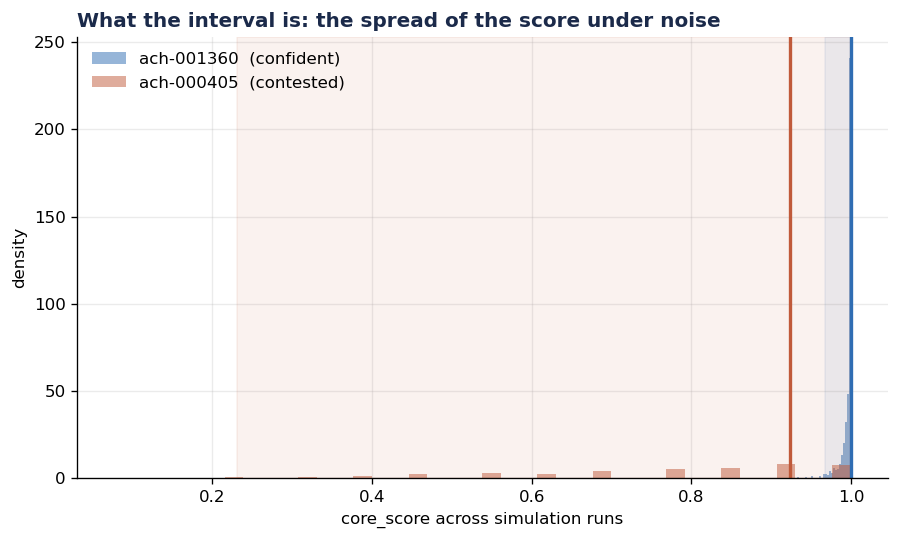

In [16]:
confident = res.iloc[0].model_id
contested = res.iloc[(res.ci_width * (res.core_score > .8)).values.argmax()].model_id
fig, ax = plt.subplots(figsize=(7.6, 4.6))
for mid, col, lab in [(confident, C2, "confident"), (contested, C1, "contested")]:
    s = scores[:, id_ix[mid]]
    ax.hist(s, bins=40, color=col, alpha=.5, density=True, label=f"{mid}  ({lab})")
    r = res.set_index("model_id").loc[mid]
    ax.axvline(r.core_score, color=col, lw=2); ax.axvspan(r.ci_lo, r.ci_hi, color=col, alpha=.08)
ax.set_xlabel("core_score across simulation runs"); ax.set_ylabel("density")
ax.set_title("What the interval is: the spread of the score under noise", fontweight="bold", color=INK, loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

## Notes and caveats

- This interval is a **stability / reproducibility** measure — how much a line's rank moves under
  realistic measurement noise. It is **not** a calibrated probability that the line is biologically
  the best; it inherits the pipeline's own "not a validated ranking" caveat.
- The interval widths depend on the noise knobs at the top. Report the values you used, and it's worth
  checking that the *ordering* of the stability numbers barely changes if you move `RNA_BASE_FLOOR` or
  `PROT_BASE` by ±50% — the relative story should hold even if absolute widths shift.
- The recompute must match the stored score (the check above). If it ever drifts, the first suspects
  are a constant that fell out of sync with `core_score.py` (e.g. `W_RNA`) or the three residual
  constants not being read from `prot_resid_stats.parquet`.
- `run_gene_ci` is per-gene and light — good for interactive use. Running it for many genes is just a
  loop, but each gene re-reads the parquet inputs, so for large batches cache those reads.